## Project Description


You work at the online store “Streamchik”, which sells computer games worldwide. Historical data on game sales, user and expert reviews, genres, and platforms (such as Xbox or PlayStation) is available from open sources. Your task is to identify patterns that determine a game’s success. This will help you focus on potentially popular products and plan advertising campaigns.

You are given data up to 2016. Let us assume that the current date is December 2016 and that you are planning a campaign for 2017. The goal is to practice working with data. It does not matter whether you predict sales for 2017 based on data from 2016 or for 2027 based on data from 2026.

The dataset contains the abbreviation ESRB (Entertainment Software Rating Board) — an organization that assigns age ratings to video games. ESRB evaluates game content and assigns an appropriate age category, such as “Adults Only”, “Early Childhood”, or “Teen”.

### Data Description

Name — game title

Platform — platform

Year_of_Release — release year

Genre — game genre

NA_sales — sales in North America (million USD)

EU_sales — sales in Europe (million USD)

JP_sales — sales in Japan (million USD)

Other_sales — sales in other regions (million USD)

Critic_Score — critics’ score (maximum 100)

User_Score — users’ score (maximum 10)

Rating — ESRB rating (Entertainment Software Rating Board). This organization assigns age ratings to video games based on their content.

⚠️ Data for 2016 may be incomplete.

In [1]:
import pandas as pd
games = pd.read_csv('/Users/fidanb/Downloads/yandex praktikum/all datasets/games.csv')
games

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [66]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
Name               16713 non-null object
Platform           16715 non-null object
Year_of_Release    16446 non-null float64
Genre              16713 non-null object
NA_sales           16715 non-null float64
EU_sales           16715 non-null float64
JP_sales           16715 non-null float64
Other_sales        16715 non-null float64
Critic_Score       8137 non-null float64
User_Score         10014 non-null object
Rating             9949 non-null object
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [67]:
games['Platform'].value_counts()

PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
GB        98
NES       98
DC        52
GEN       29
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: Platform, dtype: int64

In [68]:
games.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


In [69]:
games.corr().style.apply(lambda x: ['background: lightblue' if 1 != i < -0.5 or  1 != i > 0.5 else '' for i in x], axis=1)

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
Year_of_Release,1,-0.0925004,0.00397783,-0.168366,0.0378202,0.011411
NA_sales,-0.0925004,1,0.765335,0.449594,0.638649,0.240755
EU_sales,0.00397783,0.765335,1,0.435061,0.722792,0.220752
JP_sales,-0.168366,0.449594,0.435061,1,0.291089,0.152593
Other_sales,0.0378202,0.638649,0.722792,0.291089,1,0.198554
Critic_Score,0.011411,0.240755,0.220752,0.152593,0.198554,1


### Conclusion:

1. The dataset consists of 11 columns and 16,715 rows.
2. There is a strong correlation between the sales columns.

### Step 2. Data Preparation

1. Rename the column headers (convert them to lowercase);
2. Convert the data to appropriate data types. Describe which columns had their data types changed and explain why;
3. Handle missing values if necessary;
4. Explain why you filled in missing values in a particular way or why you chose not to do so;
5. Describe possible reasons for the missing values;
6. Pay attention to the abbreviation 'tbd' in the rating columns. Analyze this value separately and explain how it should be handled;
7. Calculate total sales across all regions and store them in a separate column.

In [70]:
def missing_values_table(games):
        mis_val = games.isnull().sum()
        mis_val_percent = 100 * games.isnull().sum() / len(games)
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        print ("Your selected dataframe has " + str(games.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        return mis_val_table_ren_columns

In [71]:
missing_values_table(games)

Your selected dataframe has 11 columns.
There are 6 columns that have missing values.


,Missing Values,% of Total Values
Critic_Score,8578,51.3
Rating,6766,40.5
User_Score,6701,40.1
Year_of_Release,269,1.6
Name,2,0.0
Genre,2,0.0


In [72]:
games.dropna(subset=['Year_of_Release'], how='all', inplace = True)
games.dropna(subset=['Name'], how='all', inplace = True)
games.dropna(subset=['Genre'], how='all', inplace = True)

In [73]:
missing_values_table(games)

Your selected dataframe has 11 columns.
There are 3 columns that have missing values.


,Missing Values,% of Total Values
Critic_Score,8461,51.5
Rating,6676,40.6
User_Score,6605,40.2


In [74]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
Name               16444 non-null object
Platform           16444 non-null object
Year_of_Release    16444 non-null float64
Genre              16444 non-null object
NA_sales           16444 non-null float64
EU_sales           16444 non-null float64
JP_sales           16444 non-null float64
Other_sales        16444 non-null float64
Critic_Score       7983 non-null float64
User_Score         9839 non-null object
Rating             9768 non-null object
dtypes: float64(6), object(5)
memory usage: 1.5+ MB


#### Rename the column headers (convert them to lowercase);

In [75]:
games.columns = [x.lower() for x in games.columns]

In [76]:
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [77]:
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


#### Convert the data to appropriate data types. Describe which columns had their data types changed and explain why;

In [78]:
games.dtypes

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

In [79]:
games['user_score'].value_counts().head()

tbd    2376
7.8     322
8       285
8.2     276
8.3     252
Name: user_score, dtype: int64

#### TBD - To Be Determined. An abbreviation used for a detail that has not been decided yet, but will be determined in the future. 

In [80]:
games['user_score'] = games['user_score'].replace({'tbd': 'NaN'})

In [81]:
games['user_score'].value_counts().head()

NaN    2376
7.8     322
8       285
8.2     276
8.3     252
Name: user_score, dtype: int64

In [82]:
games['year_of_release'] = games['year_of_release'].astype(int)
games['user_score'] = games['user_score'].astype(float)
games.dtypes

name                object
platform            object
year_of_release      int64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
dtype: object

In [83]:
games['rating'].value_counts()

E       3921
T       2905
M       1536
E10+    1393
EC         8
K-A        3
RP         1
AO         1
Name: rating, dtype: int64

##### The ESRB rating system consists of E, E10+, T, M, AO, and eC.

1. EC means "Early Childhood", suitable and/or intended for young children, Equivalent to soft G.

2. E means "Everyone", suitable for all ages. Replaced the K-A "Kids to Adults" rating in 1998, equivalent to hard G and soft PG.

3. E10+ means "Everyone 10+", the content is suitable for ages 10 and older. Introduced in 2005, equivalent to hard PG.

4. T means "Teen", the content is suitable for ages 13 and older. In the US and Canada, T-rated games may be sold to anyone, equivalent to PG-13.

5. M means "Mature", the content is suitable for ages 17 and older. In the US, a person under 17 may not legally purchase M-rated video games unless with parental supervision, and in Canada, under provincial laws, it is illegal to supply M-rated games to a person under the age of 17 years, equivalent to R.

6. AO means "Adults Only", that no under 18+ can buy a game with that rating. So far, only 29 games have successfully kept the rating. These games usually contain lots of sexually explicit material, or in rare cases, extreme violence, equivalent to NC-17.

7. RP means "Rating Pending", that is only used in advertising and the content has not yet been rated, equivalent to NR.

####  Calculate total sales across all regions and store them in a separate column.

In [84]:
games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [85]:
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


### Conclusion:
1. Removed missing values in columns where they accounted for less than 2% of the data.
2. Changed the data type in the ['year_of_release column']; I also removed 'tbd' values in the relevant rows and converted the column to float.
3. Calculated the total sales across all regions.

### Step 3. Exploratory Data Analysis

1. Examine how many games were released in different years. Are data from all periods equally important?
2. Analyze how sales changed across platforms. Identify the platforms with the highest total sales and plot their distributions by year. What is the typical lifecycle of platforms — how long does it take for new platforms to appear and old ones to disappear?
3. Select data for a relevant (current) period. Determine this period independently based on the analysis of the previous questions. The key factor is that these data should help build a forecast for 2017.
4. Do not include data from earlier years in further analysis.
5. Which platforms lead in sales, are growing, or declining? Select several potentially profitable platforms.
6. Create a box plot of global sales for each game, grouped by platform. Is there a significant difference in sales? What about average sales across different platforms? Describe the results.
7. Analyze how user and critic reviews affect sales within a single popular platform. Build a scatter plot and calculate the correlation between reviews and sales. Formulate conclusions.
8. Compare these findings with sales patterns on other platforms.
9. Examine the overall distribution of games by genre. What can be said about the most profitable genres? Are there genres with consistently high or low sales?

#### 1. Examine how many games were released in different years. Are data from all periods equally important?

In [86]:
import seaborn as sns
from plotly.offline import iplot
import matplotlib.pyplot as plt
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly as py
import plotly.graph_objs as go

In [87]:
games_by_year = games.pivot_table(index='year_of_release', values='name', aggfunc='count').sort_values(by='name',ascending=False)
games_by_year

,name
year_of_release,
2008,1427
2009,1426
2010,1255
2007,1197
2011,1136
2006,1006
2005,939
2002,829
2003,775


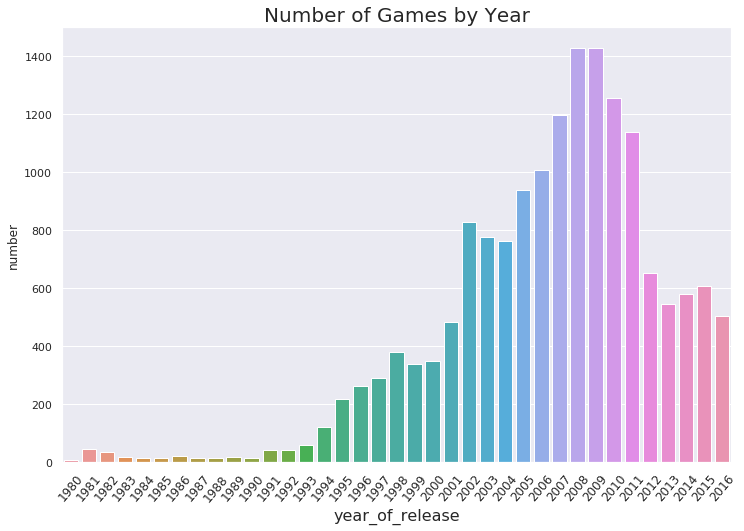

In [88]:
year_total = games.groupby(['year_of_release']).count()
sum_games_total = year_total['name']

year = year_total.index.astype(int)

plt.figure(figsize=(12,8))
ax = sns.barplot(y = sum_games_total, x = year)
ax.set_xlabel(xlabel='year_of_release', fontsize=16)
ax.set_xticklabels(labels = year, fontsize=12, rotation=50)
ax.set_ylabel(ylabel='number', fontsize=12)
ax.set_title(label='Number of Games by Year', fontsize=20)
plt.show();

### Conclusion:
I plotted a graph showing the number of games released each year. Not all data are equally important, so I used data from 2000 onwards, when game releases began to increase significantly.

#### 2. Analyze how sales have changed across platforms. Identify the platforms with the highest total sales and plot their distributions by year. What is the typical lifespan of platforms — how long does it take for new platforms to appear and old ones to disappear?

In [89]:
sales_by_platform = games.pivot_table(index=('platform'), values='total_sales', aggfunc='sum', fill_value=0).sort_values(by='total_sales', ascending=False)
sales_by_platform

,total_sales
platform,
PS2,1233.56
X360,961.24
PS3,931.34
Wii,891.18
DS,802.78
PS,727.58
PS4,314.14
GBA,312.88
PSP,289.53


In [90]:
top = pd.DataFrame(sales_by_platform.to_records())
platforms = list(top['platform'])
platforms

['PS2',
 'X360',
 'PS3',
 'Wii',
 'DS',
 'PS',
 'PS4',
 'GBA',
 'PSP',
 '3DS',
 'PC',
 'GB',
 'XB',
 'NES',
 'N64',
 'SNES',
 'GC',
 'XOne',
 '2600',
 'WiiU',
 'PSV',
 'SAT',
 'GEN',
 'DC',
 'SCD',
 'NG',
 'WS',
 'TG16',
 '3DO',
 'GG',
 'PCFX']

In [91]:
top_10 = platforms[:10]
top_platforms = games.query('platform in @top_10')
top_platforms

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
...,...,...,...,...,...,...,...,...,...,...,...,...
16708,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN,0.01
16709,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01


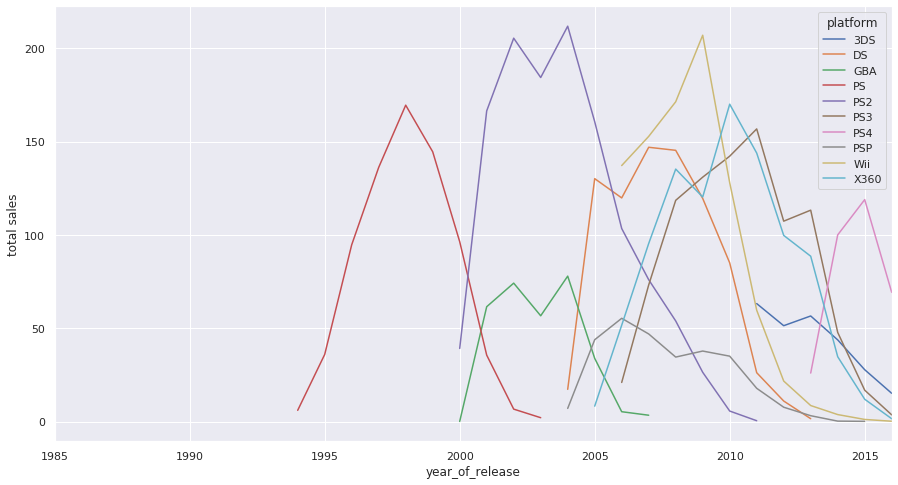

In [92]:
pivot = top_platforms.pivot_table("total_sales", index='year_of_release', columns='platform', aggfunc='sum')
sns.set()
pivot.plot(figsize=(15,8))
plt.ylabel('total sales');

### Conclusion:
I selected the top 20 most profitable platforms and created two plots. According to them, the minimum lifespan for platforms is 1–2 years; on average, popular platforms such as PS2 and Wii disappear after 3–4 years.

<font color="blue"> The plot shows that the lifespan of a platform is typically 5–10 years, and the more popular the platform, the longer its lifecycle. Platform lifecycles overlap, and it is evident that the rise of a new platform often coincides with the decline of an older one. This is especially noticeable in the case of PS1, PS2, PS3, and PS4. </font>

##### 3. Select data for the relevant current period. Determine this period independently based on the analysis of the previous questions. The key factor is that these data will help build a forecast for 2017.
#### 4. Do not include data from previous years in the analysis.
#### 5. Which platforms lead in sales, are growing, or declining? Select several potentially profitable platforms.

In [93]:
important_period = games.query('year_of_release > 2000')
important_period

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN,0.01


##### 5. Which platforms lead in sales, are growing, or declining? Select several potentially profitable platforms.

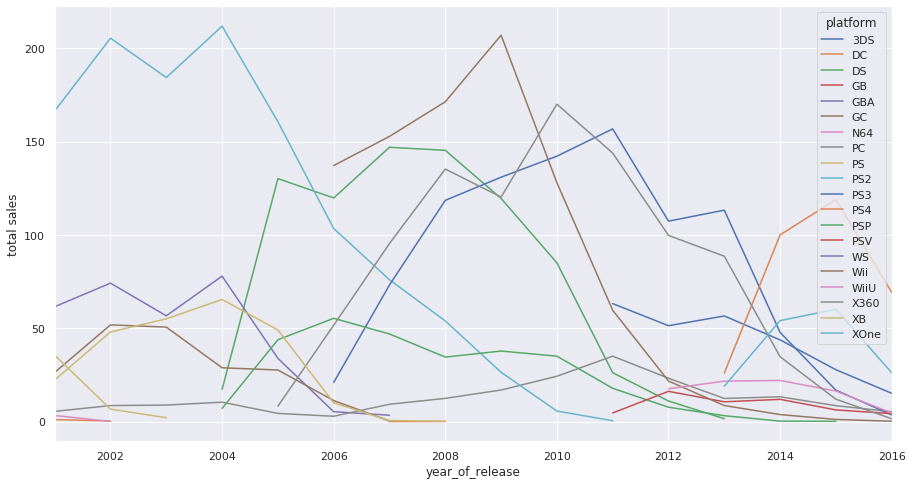

In [94]:
 important_period.pivot_table("total_sales", index='year_of_release', columns='platform', aggfunc='sum').plot(figsize=(15,8))
plt.ylabel('total sales');

In [95]:
sales=go.Bar(
                x=important_period.platform,
                y=important_period.total_sales,
                name="total_Sales",
                marker= dict(color = 'rgba(0, 0, 0)',
                            line=dict(color='rgb(25,150,153)',width=1.9)))
edit_sales=[sales]
layout=go.Layout(barmode="group",title='Sales of the top Platforms ')
fig=dict(data=edit_sales,layout=layout)
py.offline.iplot(fig,show_link=False)

### Conclusion:
According to the plots, the top 5 most popular and profitable platforms are PS2, X360, PS3, DS, and Wii. Initially, these platforms generate profit and show growth, but after 5–10 years, their profitability begins to decline.

#### 6. Create a box plot of global sales for each game, grouped by platform. Is there a significant difference in sales? What about average sales across different platforms? Describe the results.

In [96]:
import warnings
warnings.filterwarnings('ignore')

In [97]:
name_by_platform = important_period.pivot_table(index=('name','platform'), values='total_sales', aggfunc='mean').sort_values(by='total_sales',ascending=False)
name_by_platform.head()

,,total_sales
name,platform,
Wii Sports,Wii,82.54
Mario Kart Wii,Wii,35.52
Wii Sports Resort,Wii,32.77
New Super Mario Bros.,DS,29.80
Wii Play,Wii,28.91


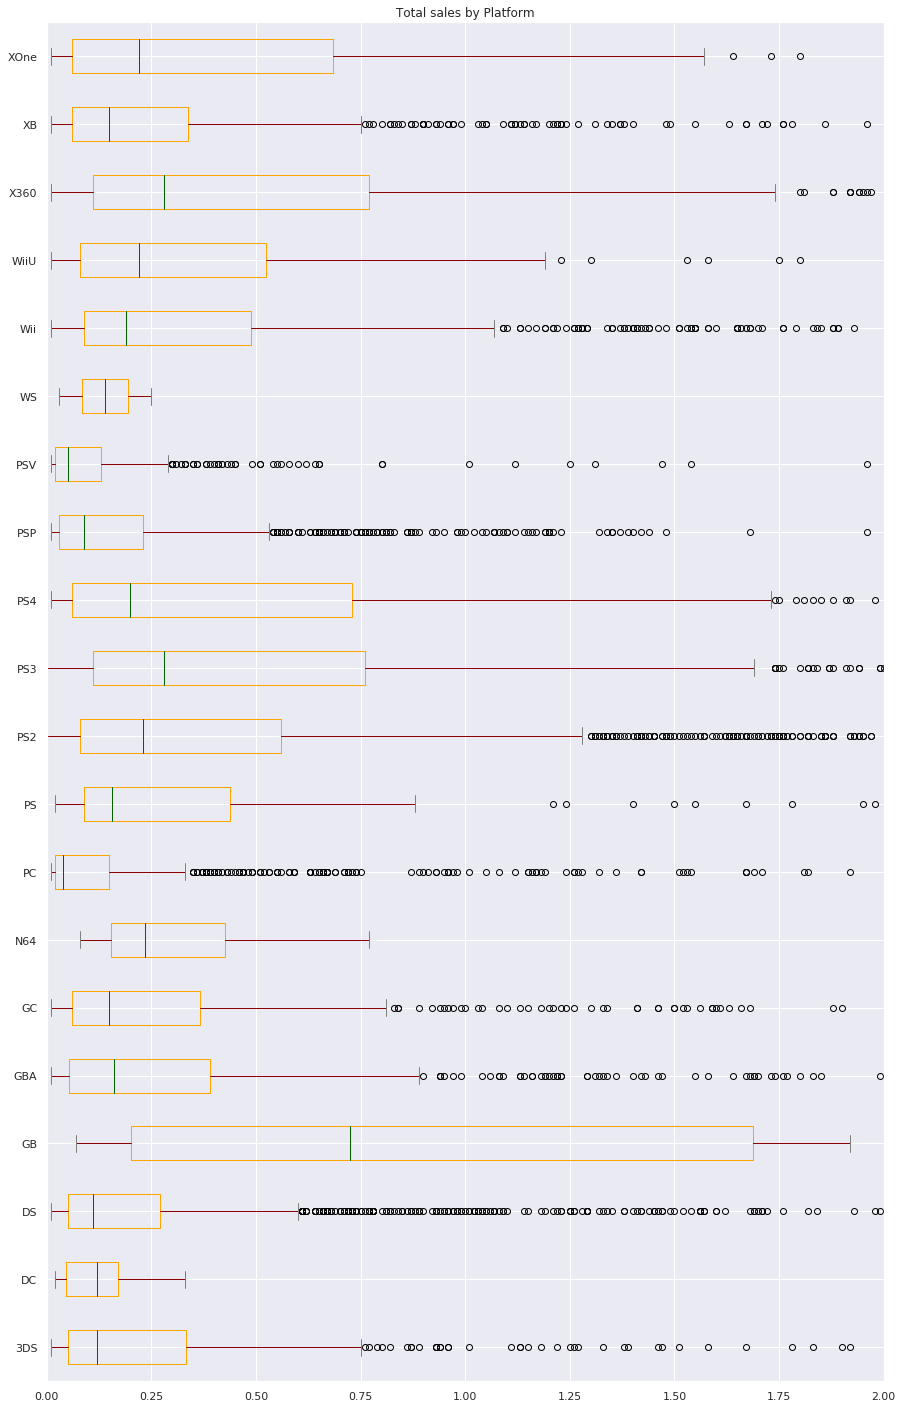

In [98]:
color = {'boxes': 'Orange', 'whiskers': 'DarkRed','medians': 'DarkGreen', 'caps': 'Gray'}
important_period.pivot_table(index='name', values='total_sales', columns='platform', aggfunc='mean').plot(title='Total sales by Platform', vert=False,color=color,kind= 'box', by=['X', 'Y'], figsize=(15,25));
ax = plt.subplot()
ax.set_xlim(0, 2);

In [99]:
layout = go.Layout(
    title='Total Release by Name and Platforms',
    yaxis=dict(
        title='Platform'
    ),
    xaxis=dict(
        title='Name'
    ),
    height=600, width=600
)

trace = go.Bar(
            x=important_period.name,
            y=important_period.platform,
            orientation = 'h',
            marker = dict(color = "rgba(10,0,0)",line = dict(color="rgb(135, 206, 250, 0.5)",width=1))
)


fig = go.Figure(data=[trace], layout=layout)
py.offline.iplot(fig, show_link=False)

### Conclusion:
The difference in sales across all platforms varies greatly. The plot shows that the top 5 most popular platforms have many outliers, with a wide range of global sales. The boxes are right-skewed, with the median lower than the mean. The last plot also shows the number of games for each platform, which may explain the large spread observed in the box plot.

#### 7. Analyze how user and critic reviews affect sales within a single popular platform. Create a scatter plot and calculate the correlation between reviews and sales. Formulate conclusions.

In [100]:
ps2_platform = important_period.query('platform == "PS2"')
ps2_platform

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
17,Grand Theft Auto: San Andreas,PS2,2004,Action,9.43,0.40,0.41,10.57,95.0,9.0,M,20.81
24,Grand Theft Auto: Vice City,PS2,2002,Action,8.41,5.49,0.47,1.78,95.0,8.7,M,16.15
28,Gran Turismo 3: A-Spec,PS2,2001,Racing,6.85,5.09,1.87,1.16,95.0,8.4,E,14.97
38,Grand Theft Auto III,PS2,2001,Action,6.99,4.51,0.30,1.30,97.0,8.5,M,13.10
48,Gran Turismo 4,PS2,2004,Racing,3.01,0.01,1.10,7.53,89.0,8.5,E,11.65
...,...,...,...,...,...,...,...,...,...,...,...,...
16670,Sugar + Spice! Anoko no Suteki na Nanimokamo,PS2,2008,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16671,Kanokon: Esuii,PS2,2008,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16683,Scarlett: Nichijou no Kyoukaisen,PS2,2008,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16689,Real Rode,PS2,2008,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01


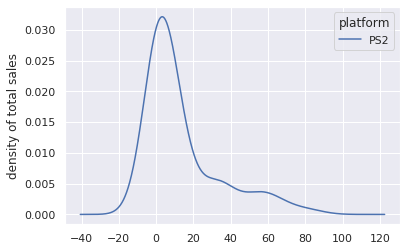

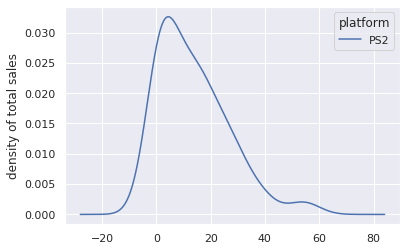

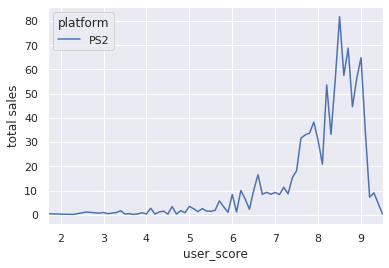

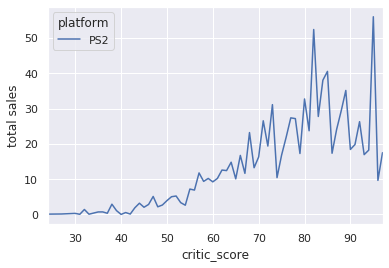

In [101]:
ps2_platform.pivot_table("total_sales", index='user_score', columns='platform', aggfunc='sum').plot(kind='kde')
plt.ylabel('density of total sales');
ps2_platform.pivot_table("total_sales", index='critic_score', columns='platform', aggfunc='sum').plot(kind='kde')
plt.ylabel('density of total sales');
ps2_platform.pivot_table("total_sales", index=('user_score'), columns='platform', aggfunc='sum').plot()
plt.ylabel('total sales');
ps2_platform.pivot_table("total_sales", index=('critic_score'), columns='platform', aggfunc='sum').plot()
plt.ylabel('total sales');

In [102]:
ps2_platform['user_score'].corr(ps2_platform['total_sales'])

0.17323853086163116

In [103]:
ps2_platform['total_sales'].corr(ps2_platform['critic_score'])

0.3929255725800446

In [104]:
pd.pivot_table(important_period, index= ('user_score','critic_score','platform'), values= "total_sales", aggfunc='sum').sort_values(by='critic_score',ascending=False).head()

,,,total_sales
user_score,critic_score,platform,
7.9,98.0,X360,11.00
7.5,98.0,PS3,10.50
8.3,97.0,PS4,12.62
8.1,97.0,X360,16.27
8.5,97.0,PS2,13.10


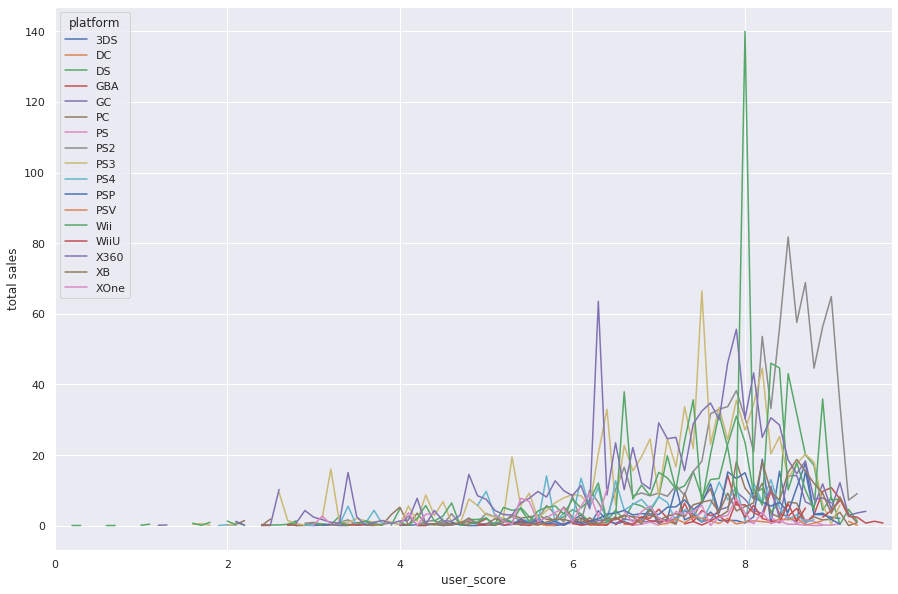

In [105]:
important_period.pivot_table("total_sales", index='user_score', columns='platform', aggfunc='sum').plot(figsize=(15,10))
plt.ylabel('total sales');

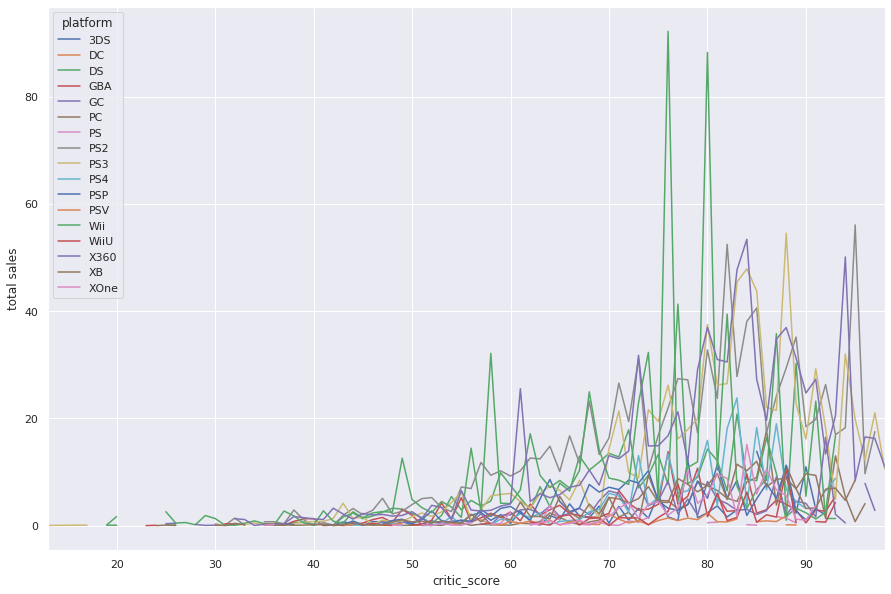

In [106]:
important_period.pivot_table("total_sales", index='critic_score', columns='platform', aggfunc='sum').plot(figsize=(15,10))
plt.ylabel('total sales');

In [107]:
important_period['user_score'].corr(important_period['total_sales'])

0.08032762873743618

In [108]:
important_period['total_sales'].corr(important_period['critic_score'])

0.23810220661479325

### Conclusion:
I selected the most popular platform, PS2. The plots show that user and critic reviews have roughly similar density distributions. However, in the scatter plot of all sales versus reviews, it is visible that sales decrease by approximately 1.5 times with lower critic reviews. Calculations show a weak correlation between reviews and sales, but the correlation between critic reviews and sales is roughly twice as strong as the correlation between user reviews and sales.

#### 8. Compare these findings with sales on other platforms.

In [109]:
other_top_platforms = important_period.query('platform in ("PS3","X360","Wii","DS")')
other_top_platforms

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
...,...,...,...,...,...,...,...,...,...,...,...,...
16698,Mega Brain Boost,DS,2008,Puzzle,0.01,0.00,0.00,0.00,48.0,NaN,E,0.01
16700,Mezase!! Tsuri Master DS,DS,2009,Sports,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16704,Plushees,DS,2008,Simulation,0.01,0.00,0.00,0.00,NaN,NaN,E,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01


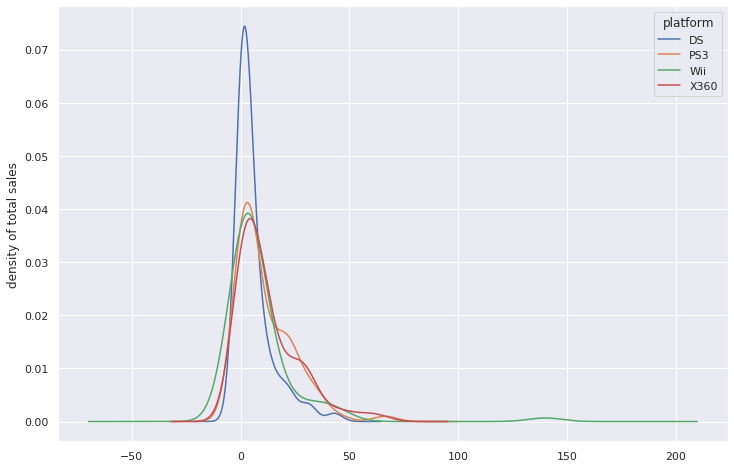

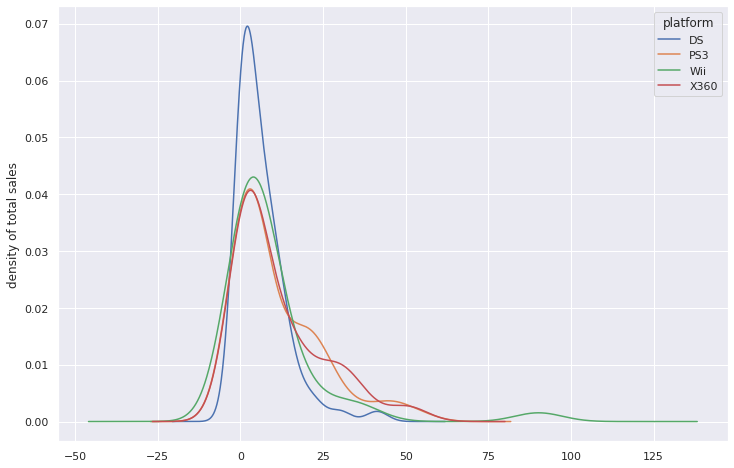

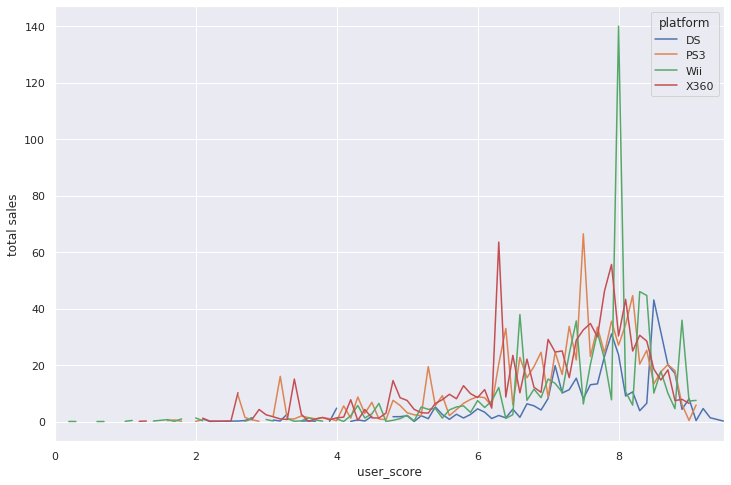

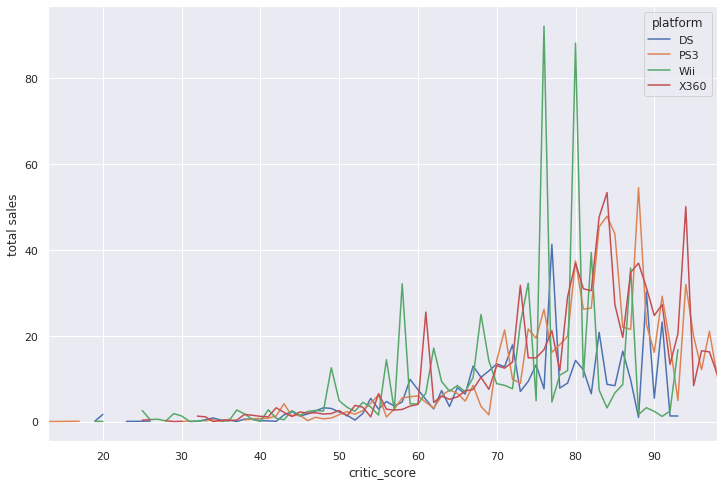

In [110]:
other_top_platforms.pivot_table("total_sales", index=('user_score'), columns='platform', aggfunc='sum').plot(kind='kde',figsize=(12,8))
plt.ylabel('density of total sales');
other_top_platforms.pivot_table("total_sales", index=('critic_score'), columns='platform', aggfunc='sum').plot(kind='kde',figsize=(12,8))
plt.ylabel('density of total sales');
other_top_platforms.pivot_table("total_sales", index=('user_score'), columns='platform', aggfunc='sum').plot(figsize=(12,8))
plt.ylabel('total sales');
other_top_platforms.pivot_table("total_sales", index=('critic_score'), columns='platform', aggfunc='sum').plot(figsize=(12,8))
plt.ylabel('total sales');

In [111]:
other_top_platforms['user_score'].corr(other_top_platforms['total_sales'])

0.10809502021019277

In [112]:
other_top_platforms['total_sales'].corr(other_top_platforms['critic_score'])

0.25739548188877437

### Conclusion:
I selected the remaining four platforms: DS, PS3, Wii, and X360. According to the plots, user and critic reviews also have roughly similar density distributions. However, in the scatter plot of all sales versus reviews, it is visible that sales decrease by approximately 1.5 times with lower critic reviews. Calculations show a weak correlation between reviews and sales, but the correlation between critic reviews and sales is about twice as strong as the correlation between user reviews and sales.

#### 9. Examine the overall distribution of games by genre. What can be said about the most profitable genres? Are there genres with consistently high or low sales?

In [113]:
genrelist = list(important_period["genre"].unique())
genreearns = []
for i in genrelist:
    x = important_period[important_period["genre"] == i]
    sums = sum(x.total_sales)
    genreearns.append(sums)
    
data = pd.DataFrame({"genrelist": genrelist, "genreearns": genreearns})
new_index = (data["genreearns"].sort_values(ascending=False)).index.values
sorted_data = data.reindex(new_index)

genre_sales = go.Bar(
                x = sorted_data.genrelist,
                y = sorted_data.genreearns,
                name = "Total Sales by Genres",
                marker = dict(color = "rgba(135, 206, 250, 0.5)",line = dict(color="rgb(0,0,0)",width=1)))
data = [genre_sales]
layout = dict(title = "Total Sales by Genres")
fig = go.Figure(data = data, layout = layout)
py.offline.iplot(fig,show_link=False)

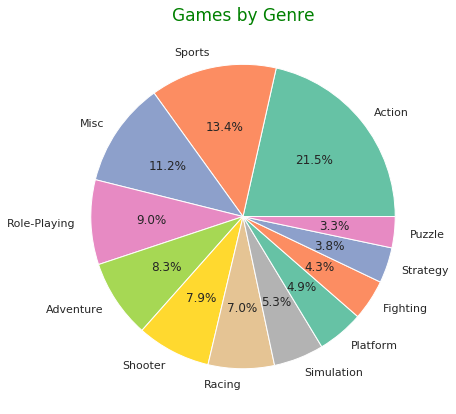

In [114]:
labels=important_period.genre.value_counts().index
explode = [0,0,0,0,0,0,0,0,0,0,0,0]
sizes = important_period.genre.value_counts().values
# visual
plt.figure(figsize = (7,7))
plt.pie(sizes, explode=explode, labels=labels, colors=sns.color_palette('Set2'), autopct='%1.1f%%')
plt.title('Games by Genre',fontsize = 17,color = 'green');

### Conclusion:
The first plot shows that the top 5 most popular genres are Action, Sports, Shooter, Misc, and Role-Playing. The second plot illustrates the overall share of each genre for the relevant period.

### Step 4. Create a User Profile for Each Region
Identify key characteristics for users in each region (NA, EU, JP):

#### 1. The most popular platforms (top 5). Describe the differences in their sales shares.

In [115]:
important_period.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91


In [116]:
na_sales=go.Bar(
                x=important_period.platform,
                y=important_period.na_sales,
                name="NA_Sales",
                marker= dict(color = 'rgba(60, 60, 60)',
                            line=dict(color='rgb(60, 60, 60)',width=1.9)))
eu_sales=go.Bar(
                x=important_period.platform,
                y=important_period.eu_sales,
                name="EU_Sales",
                marker=dict(color = 'rgba(56, 140, 200, 0.7)',
                           line=dict(color='rgb(56, 140, 200, 0.7)',width=1.9)))
jp_sales=go.Bar(
                x=important_period.platform,
                y=important_period.jp_sales,
                name="JP_Sales",
                marker=dict(color = 'rgba(251,154,153)',
                           line=dict(color='rgb(251,154,153)',width=1.9)))

edit_sales=[na_sales,eu_sales,jp_sales]
layout=go.Layout(barmode="group",title='Sales of the top 5 Platforms in EU,JP,NA')
fig=dict(data=edit_sales,layout=layout)
py.offline.iplot(fig,show_link=False)

#### Conclusion:

1. For the NA region, the most popular platform is X360; for EU, it is PS3; for JP, it is DS.
2. For NA, the second most popular platform is PS2; for EU, PS2; for JP, PS2.
3. For NA, the third is Wii; for EU, Wii; for JP, 3DS.
4. For NA, the fourth is PS3; for EU, DS; for JP, PS3.
5. For NA, the fifth is DS; for EU, PS4; for JP, Wii.

Overall: NA leads in sales, EU generates about half the revenue of NA, and JP accounts for roughly one-third of NA's sales.


#### 2. The most popular genres (top 5). Explain the differences.

In [117]:
na_sales=go.Bar(
                x=important_period.genre,
                y=important_period.na_sales,
                name="NA_Sales",
                marker= dict(color = 'rgba(60, 60, 60)',
                            line=dict(color='rgb(254,224,144)',width=1.9)))
eu_sales=go.Bar(
                x=important_period.genre,
                y=important_period.eu_sales,
                name="EU_Sales",
                marker=dict(color = 'rgba(224,243,248)',
                           line=dict(color='rgb(56, 140, 200, 0.7)',width=1.9)))
jp_sales=go.Bar(
                x=important_period.genre,
                y=important_period.jp_sales,
                name="JP_Sales",
                marker=dict(color = 'rgba(0,0,0)',
                           line=dict(color='rgb(251,154,153)',width=1.9)))

edit_sales=[na_sales,eu_sales,jp_sales]
layout=go.Layout(barmode="group",title='Sales of the top 5 Platforms in EU,JP,NA')
fig=dict(data=edit_sales,layout=layout)
py.offline.iplot(fig,show_link=False)

### Conclusion:

1. The most popular genre in NA and EU is Action; in JP, it is Role-Playing.
2. The second most popular genre in NA and EU is Sports; in JP, it is Action.
3. The third most popular genre in NA and EU is Shooter; in JP, it is Misc.
4. The fourth most popular genre in NA and EU is Misc; in JP, it is Sports.
5. The fifth most popular genre: NA — Role-Playing, EU — Racing, JP — Platform.

#### 3. Does the ESRB rating affect sales in a particular region?

In [118]:
na_sales=go.Bar(
                x=important_period.rating,
                y=important_period.na_sales,
                name="NA_Sales",
                marker= dict(color = 'rgba(60, 60, 60)',
                            line=dict(color='rgb(244,109,67)',width=1.9)))
eu_sales=go.Bar(
                x=important_period.rating,
                y=important_period.eu_sales,
                name="EU_Sales",
                marker=dict(color = 'rgba(56, 140, 200, 0.7)',
                           line=dict(color='rgb(156, 30, 130, 0.7)',width=1.9)))
jp_sales=go.Bar(
                x=important_period.rating,
                y=important_period.jp_sales,
                name="JP_Sales",
                marker=dict(color = 'rgba(0,0,0)',
                           line=dict(color='rgb(251,154,153)',width=1.9)))

edit_sales=[na_sales,eu_sales,jp_sales]
layout=go.Layout(barmode="group",title='Sales of the top 5 Platforms in EU,JP,NA')
fig=dict(data=edit_sales,layout=layout)
py.offline.iplot(fig,show_link=False)

### Conclusion:

1. In all regions, games with the “E” (Everyone) rating lead in sales.
2. The second most popular rating is “M” (Mature) for NA and EU, and “T” (Teen) for JP.
3. The third most popular rating is “T” (Teen) for NA and EU, and “M” (Mature) for JP.
4. The fourth most popular rating in all regions is “E10+” (Everyone 10+).

### Step 5. Hypothesis Testing

1. The average user ratings for the Xbox One and PC platforms are equal.
2. The average user ratings for the Action and Sports genres are different.

Set the significance level alpha independently.

Explain:

How you formulated the null and alternative hypotheses;
Which statistical test you used to check the hypotheses and why.

#### 1. The average user ratings for the Xbox One and PC platforms are equal.

In [ ]:
important_period['platform'].value_counts()

In [120]:
from scipy import stats as st
games.query('platform == "XOne"')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
99,Call of Duty: Black Ops 3,XOne,2015,Shooter,4.59,2.11,0.01,0.68,NaN,NaN,NaN,7.39
165,Grand Theft Auto V,XOne,2014,Action,2.81,2.19,0.00,0.47,97.0,7.9,M,5.47
179,Call of Duty: Advanced Warfare,XOne,2014,Shooter,3.22,1.55,0.01,0.48,81.0,5.4,M,5.26
242,Halo 5: Guardians,XOne,2015,Shooter,2.78,1.27,0.03,0.41,84.0,6.4,T,4.49
270,Fallout 4,XOne,2015,Role-Playing,2.51,1.32,0.01,0.38,88.0,6.2,M,4.22
...,...,...,...,...,...,...,...,...,...,...,...,...
16630,Sébastien Loeb Rally Evo,XOne,2016,Racing,0.00,0.01,0.00,0.00,63.0,8.2,E,0.01
16643,Rugby Challenge 3,XOne,2016,Sports,0.00,0.01,0.00,0.00,NaN,6.6,E,0.01
16645,ZombiU,XOne,2016,Action,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01
16660,Prison Architect,XOne,2016,Action,0.01,0.00,0.00,0.00,74.0,6.7,NaN,0.01


In [125]:
rating_xbox = important_period.query('platform == "XOne"')
rating_xbox['user_score'].mean()

6.521428571428572

In [126]:
rating_xbox

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
99,Call of Duty: Black Ops 3,XOne,2015,Shooter,4.59,2.11,0.01,0.68,NaN,NaN,NaN,7.39
165,Grand Theft Auto V,XOne,2014,Action,2.81,2.19,0.00,0.47,97.0,7.9,M,5.47
179,Call of Duty: Advanced Warfare,XOne,2014,Shooter,3.22,1.55,0.01,0.48,81.0,5.4,M,5.26
242,Halo 5: Guardians,XOne,2015,Shooter,2.78,1.27,0.03,0.41,84.0,6.4,T,4.49
270,Fallout 4,XOne,2015,Role-Playing,2.51,1.32,0.01,0.38,88.0,6.2,M,4.22
...,...,...,...,...,...,...,...,...,...,...,...,...
16630,Sébastien Loeb Rally Evo,XOne,2016,Racing,0.00,0.01,0.00,0.00,63.0,8.2,E,0.01
16643,Rugby Challenge 3,XOne,2016,Sports,0.00,0.01,0.00,0.00,NaN,6.6,E,0.01
16645,ZombiU,XOne,2016,Action,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01
16660,Prison Architect,XOne,2016,Action,0.01,0.00,0.00,0.00,74.0,6.7,NaN,0.01


In [127]:
rating_xbox.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,total_sales
count,247.000000,247.000000,247.000000,247.000000,247.000000,169.000000,182.000000,247.000000
mean,2014.951417,0.377004,0.208866,0.001377,0.057773,73.325444,6.521429,0.645020
std,0.952995,0.630618,0.365306,0.005153,0.094221,12.953465,1.380941,1.036139
min,2013.000000,0.000000,0.000000,0.000000,0.000000,20.000000,1.600000,0.010000
25%,2014.000000,0.030000,0.020000,0.000000,0.010000,66.000000,5.800000,0.060000
50%,2015.000000,0.120000,0.070000,0.000000,0.020000,76.000000,6.800000,0.220000
75%,2016.000000,0.385000,0.220000,0.000000,0.060000,82.000000,7.500000,0.685000
max,2016.000000,4.590000,2.190000,0.040000,0.680000,97.000000,9.200000,7.390000


In [128]:
rating_pc = important_period.query('platform == "PC"')
rating_pc['user_score'].mean()

7.025274725274725

In [129]:
rating_pc.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,total_sales
count,910.000000,910.000000,910.000000,910.000000,910.000000,683.000000,728.000000,910.000000
mean,2009.561538,0.066923,0.131747,0.000088,0.022187,75.693997,7.025275,0.220945
std,3.685976,0.256659,0.379404,0.002652,0.068680,11.105667,1.522312,0.587085
min,2001.000000,0.000000,0.000000,0.000000,0.000000,33.000000,1.400000,0.010000
25%,2007.000000,0.000000,0.020000,0.000000,0.000000,70.000000,6.200000,0.020000
50%,2010.000000,0.000000,0.030000,0.000000,0.010000,77.000000,7.500000,0.040000
75%,2012.000000,0.020000,0.090000,0.000000,0.020000,84.000000,8.200000,0.150000
max,2016.000000,2.570000,6.420000,0.080000,1.180000,96.000000,9.300000,8.010000


According to the hypothesis, the average user ratings for the Xbox One and PC platforms should be equal. Let’s check the p-value.

In [130]:
# Two-sided hypothesis
alpha = .05

results = st.stats.ttest_ind(rating_xbox.dropna()['user_score'], rating_pc.dropna()['user_score'], nan_policy='propagate', equal_var = False)

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")
    

p-значение: 1.475418801323855e-05
Отвергаем нулевую гипотезу


We reject the null hypothesis, as the average user ratings are not equal.

#### 2. The average user ratings for the Action and Sports genres are different.

In [118]:
genre_action = important_period.query('genre == "Action"')
genre_action['user_score'].mean()

7.047308781869688

In [119]:
genre_action.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,total_sales
count,3035.000000,3035.000000,3035.000000,3035.000000,3035.000000,1821.000000,1765.000000,3035.000000
mean,2009.305766,0.242003,0.150161,0.042336,0.057157,66.619440,7.047309,0.491657
std,4.166613,0.549597,0.404707,0.146881,0.247503,14.057677,1.415808,1.139154
min,2001.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.300000,0.010000
25%,2006.000000,0.010000,0.000000,0.000000,0.000000,57.000000,6.300000,0.060000
50%,2009.000000,0.090000,0.030000,0.000000,0.010000,68.000000,7.300000,0.180000
75%,2013.000000,0.240000,0.140000,0.030000,0.050000,77.000000,8.000000,0.460000
max,2016.000000,9.660000,9.090000,3.960000,10.570000,98.000000,9.500000,21.050000


In [120]:
genre_sports = important_period.query('genre == "Sports"')
genre_sports['user_score'].mean()

6.9409943714821765

In [121]:
genre_sports.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,total_sales
count,1898.000000,1898.000000,1898.000000,1898.000000,1898.000000,1129.000000,1066.000000,1898.000000
mean,2007.402529,0.298546,0.173767,0.036628,0.065179,72.004429,6.940994,0.574120
std,3.945762,1.132561,0.860177,0.181877,0.267057,13.867566,1.623240,2.294477
min,2001.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.200000,0.000000
25%,2004.000000,0.030000,0.000000,0.000000,0.000000,65.000000,6.100000,0.090000
50%,2008.000000,0.110000,0.020000,0.000000,0.010000,75.000000,7.400000,0.210000
75%,2010.000000,0.300000,0.110000,0.000000,0.050000,82.000000,8.100000,0.540000
max,2016.000000,41.360000,28.960000,3.770000,8.450000,97.000000,9.500000,82.540000


According to the hypothesis, the average user ratings for the Action and Sports genres should be equal. Let’s check the p-value.

In [122]:
alpha = .05

results = st.ttest_ind(genre_action.dropna()['user_score'], genre_sports.dropna()['user_score'], nan_policy='propagate',equal_var = False)

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 0.7986416811611282
Не получилось отвергнуть нулевую гипотезу


The hypothesis confirmed that the average user ratings for the Action and Sports genres are approximately equal. Therefore, we could not prove that the average user ratings for the Action and Sports genres are different.

### Overall Conclusion

During the regional analysis for EU, NA, and JP, the following results were obtained:

1. The top 5 most popular and profitable platforms are PS2, PS3, DS, Wii, and X360. These platforms are popular across all regions, although their relative popularity may vary.
2. The top 5 most popular genres are Action, Sports, Shooter, Misc, and Role-Playing. Depending on the region, they may generate higher or lower sales relative to each other.
3. In all regions, the ESRB rating “E” (Everyone) leads in sales.